作者：东哥起飞

本篇文章来源于[《100天成为风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky) 评估指标篇-AUC指标计算

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve
import os, re, sys
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

In [2]:
import matplotlib as mpl
import sklearn as sk
print('pandas:%s'%(pd.__version__))
print('numpy:%s'%(np.__version__))
print('matplotlib:%s'%(mpl.__version__))
print('seaborn:%s'%(sns.__version__))
print('sklearn:%s'%(sk.__version__))

pandas:2.0.0
numpy:1.23.5
matplotlib:3.7.1
seaborn:0.12.2
sklearn:1.3.2


## 0. 读取数据

In [3]:
df = pd.read_csv('data.csv')
df.shape

(56961, 4)

In [4]:
df

,xgb_prob,xgb_score,target,xgb_pred
0,1.000000e+00,85.0000,1,1
1,1.000000e+00,85.0000,1,1
2,5.651352e-01,454.6351,1,0
3,1.000000e+00,85.0000,1,1
4,1.000000e+00,85.0000,1,1
...,...,...,...,...
56956,1.410769e-20,935.0000,0,0
56957,4.544995e-04,934.6137,0,0
56958,4.149218e-04,934.6473,0,0
56959,8.523716e-04,934.2755,0,0


In [5]:
df.target.value_counts()

target
0    56863
1       98
Name: count, dtype: int64

In [6]:
preds  = df['xgb_prob']
y_true = df['target']

## 1. 混淆矩阵

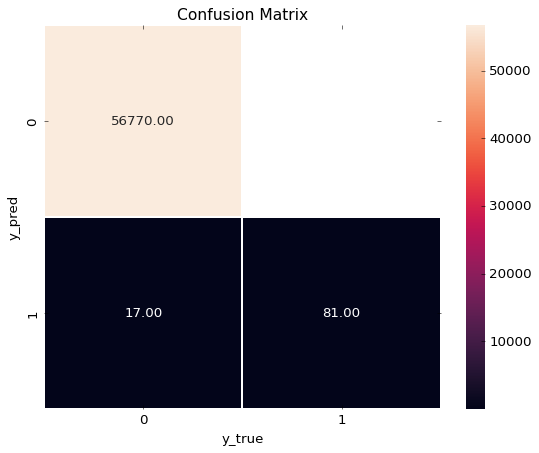

In [312]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, df['xgb_pred'])  # 计算真实标签和预测标签之间的混淆矩阵  
mask = np.zeros_like(cm)
mask[np.triu_indices_from(mask,1)] = True

plt.style.use('classic')
plt.figure(facecolor='white',dpi=80)
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', linewidths=0.2)
plt.xlabel('y_true',fontsize=12)
plt.ylabel('y_pred',fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [313]:
cm

array([[56770,    93],
       [   17,    81]], dtype=int64)

## 2. P-R曲线

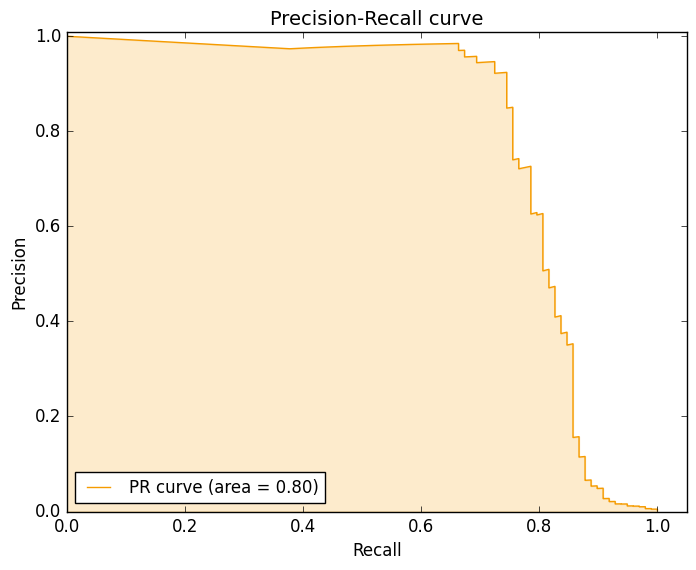

In [314]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

average_precision = average_precision_score(df['target'], df['xgb_prob'])
precision, recall, thres = precision_recall_curve(df['target'], df['xgb_prob'])

plt.style.use('classic')
plt.figure(facecolor='white',dpi=100)
plt.plot(recall, precision, color='#F59B00', alpha=1, label='PR curve (area = {:.2f})'.format(average_precision))
plt.fill_between(recall, precision, alpha=0.2, color='#F59B00')
plt.xlabel('Recall',fontsize=12)
plt.ylabel('Precision',fontsize=12)
plt.ylim([0.0, 1.01])
plt.xlim([0.0, 1.05])
plt.title('Precision-Recall curve', fontsize=14)
plt.legend(loc="best",fontsize=12)

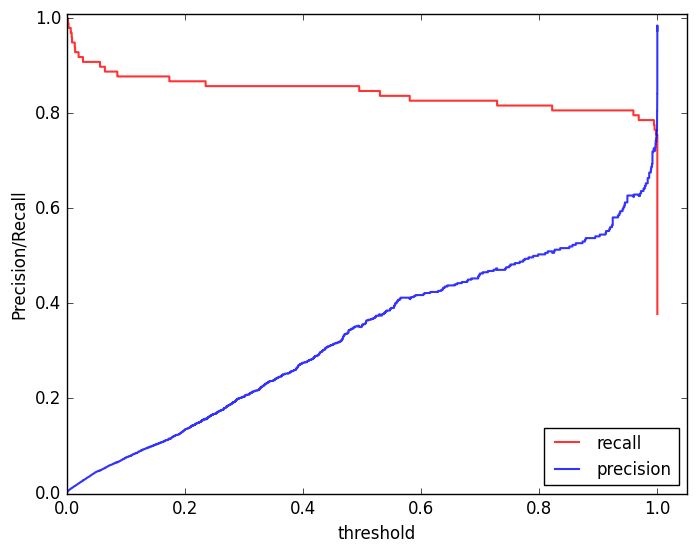

In [315]:
# Precision and Recall vs. threshold 
plt.style.use('classic')
plt.figure(facecolor='white',dpi=100)
plt.step(thres, recall[:-1], color='r', alpha=0.8, where='post', linewidth=1.5, label='recall')
plt.step(thres, precision[:-1], color='b', alpha=0.8, where='post', linewidth=1.5, label='precision')
plt.xlabel('threshold',fontsize=12)
plt.ylabel('Precision/Recall',fontsize=12)
plt.ylim([0.0, 1.01])
plt.xlim([0.0, 1.05])
plt.legend(loc="best",fontsize=12)
plt.show()

## 3. ROC曲线图

In [316]:
def roc_plot(y_true, y_preds, datatype:str, asc=1):
    """
    ROC曲线图
    @param y_true:   y标签[0,1]
    @param y_score:  预测序列
    @param datatype: 数据集名称 
    @param asc:      是否升序，值为0或1；asc=1时preds是概率，asc=0时preds是分数
    """
    from sklearn.metrics import roc_auc_score, roc_curve, auc
    
    if asc == 1:
        y = y_true
    else:
        y = 1-y_true
        
    fpr, tpr, _ = roc_curve(y, y_preds)
    auc = round(roc_auc_score(y, y_preds), 4)
    
    plt.style.use('classic')
    plt.figure(facecolor='white',dpi=80)
    plt.plot(fpr, tpr, label='{}_auc: '.format(datatype)+str(auc), color='red', linestyle='-', linewidth=1.5)
    plt.fill_between(fpr, tpr, alpha=0.2, color='#F08080')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.xlim(-0.01,1)
    plt.ylim(0,1.01)
    plt.title("ROC curve of %s (AUC = %.4f)" % (datatype, auc), fontsize=14)
    plt.legend(fontsize=12, loc='best')
    
    return auc

0.0155

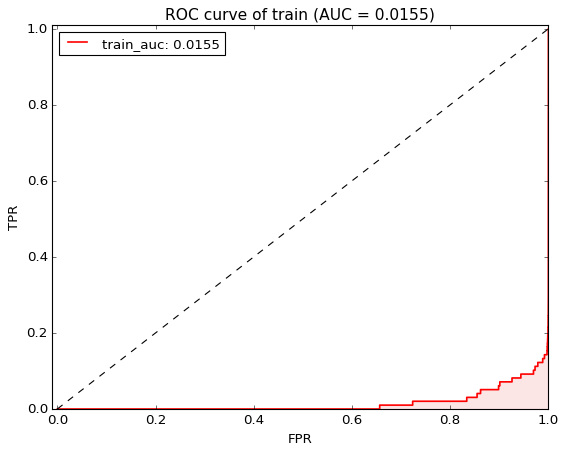

In [319]:
roc_plot(df['target'], df['xgb_score'], 'train', asc=1)

## 番外

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

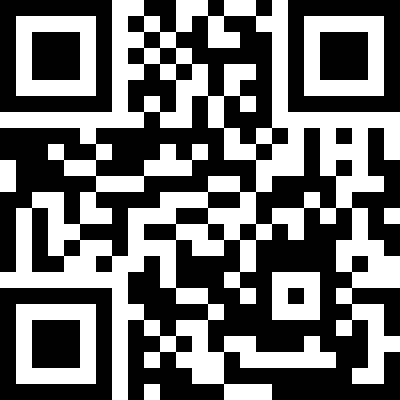